In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\sakil\Downloads\Groceries_dataset.csv.zip")
print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (38765, 3)


In [5]:
print(df.describe(include='object').T)

                 count unique         top  freq
Date             38765    728  21-01-2015    96
itemDescription  38765    167  whole milk  2502


In [6]:
print(df.dtypes)

Member_number       int64
Date               object
itemDescription    object
dtype: object


In [9]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)
print(df.isnull().sum())

Duplicate Rows: 759
Member_number      0
Date               0
itemDescription    0
dtype: int64


In [10]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


In [11]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Member_number      0
Date               0
itemDescription    0
dtype: int64


In [16]:
print("Unique Customers:",
      df['Member_number'].nunique())
print("Unique Products:",
      df['itemDescription'].nunique())

Unique Customers: 3898
Unique Products: 167


In [14]:
print(df['itemDescription']
      .value_counts()
      .head(10))

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64


In [18]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.head())

   Member_number       Date   itemDescription
0           1808 2015-07-21    tropical fruit
1           2552 2015-01-05        whole milk
2           2300 2015-09-19         pip fruit
3           1187 2015-12-12  other vegetables
4           3037 2015-02-01        whole milk


C:\Users\sakil\AppData\Local\Temp\ipykernel_30368\3939411514.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [19]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print(df.head())
monthly_sales = df.groupby('Month').size()

print(monthly_sales)

   Member_number       Date   itemDescription  Year  Month  Day
0           1808 2015-07-21    tropical fruit  2015      7   21
1           2552 2015-01-05        whole milk  2015      1    5
2           2300 2015-09-19         pip fruit  2015      9   19
3           1187 2015-12-12  other vegetables  2015     12   12
4           3037 2015-02-01        whole milk  2015      2    1
Month
1     3324
2     2997
3     3133
4     3260
5     3408
6     3264
7     3300
8     3496
9     3059
10    3261
11    3254
12    3009
dtype: int64


In [21]:
monthly_sales = df.groupby('Month').size()
print(monthly_sales)

Month
1     3324
2     2997
3     3133
4     3260
5     3408
6     3264
7     3300
8     3496
9     3059
10    3261
11    3254
12    3009
dtype: int64


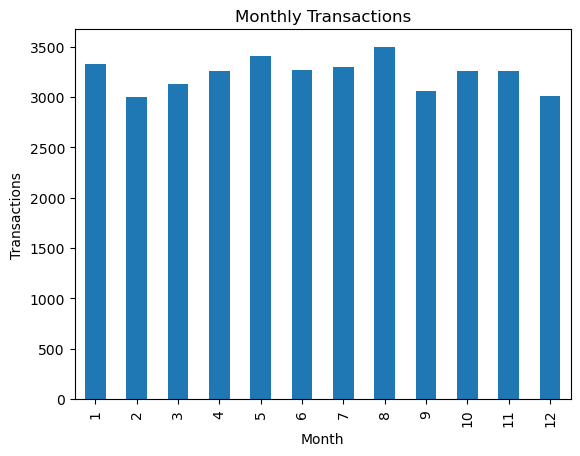

In [23]:
monthly_sales.plot(
    kind='bar'
)
plt.title("Monthly Transactions")
plt.xlabel("Month")
plt.ylabel("Transactions")

plt.show()

In [25]:
daily_sales = df.groupby('Day').size()

print(daily_sales)

Day
1     1259
2     1287
3     1393
4     1220
5     1217
6     1284
7     1245
8     1351
9     1175
10    1265
11    1316
12    1244
13    1341
14    1341
15    1245
16    1158
17    1181
18    1285
19    1272
20    1214
21    1354
22    1272
23    1277
24    1290
25    1229
26    1351
27    1327
28    1375
29    1124
30    1201
31     672
dtype: int64


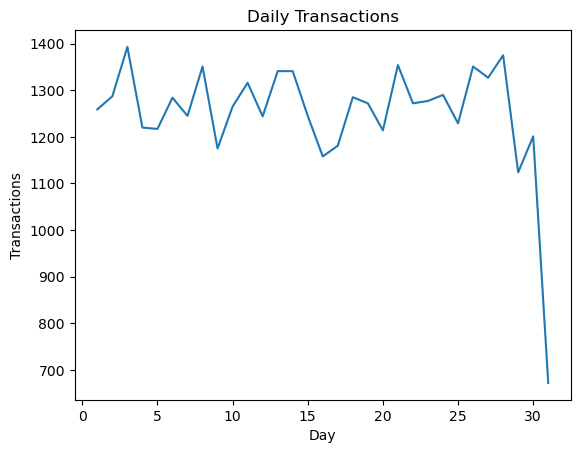

In [26]:
daily_sales.plot(
    kind='line'
)
plt.title("Daily Transactions")
plt.xlabel("Day")
plt.ylabel("Transactions")

plt.show()

In [27]:
top_customers = df['Member_number']\
                .value_counts()\
                .head(10)

print(top_customers)

Member_number
3180    36
3737    33
3050    33
2051    33
2625    31
3915    31
2433    31
2271    31
3872    30
3289    29
Name: count, dtype: int64


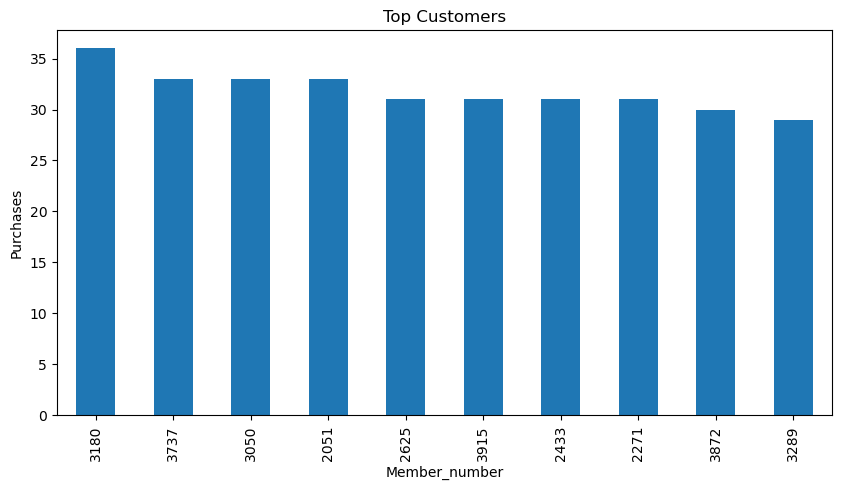

In [28]:
plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title("Top Customers")
plt.ylabel("Purchases")

plt.show()

In [29]:
print(df['itemDescription']
      .value_counts()
      .tail(10))

itemDescription
whisky                   8
salad dressing           6
make up remover          5
toilet cleaner           5
frozen chicken           5
rubbing alcohol          5
bags                     4
baby cosmetics           3
kitchen utensil          1
preservation products    1
Name: count, dtype: int64


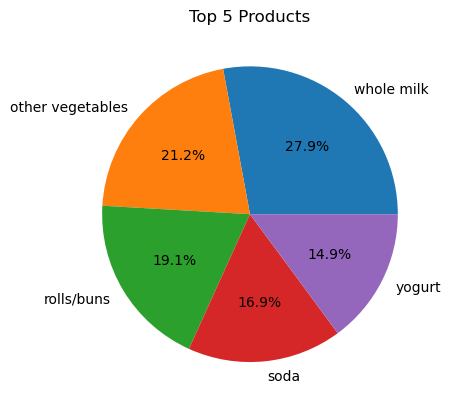

In [36]:
top5 = df['itemDescription']\
        .value_counts()\
        .head(5)
plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%'
)
plt.title("Top 5 Products")
plt.show()

In [33]:
transactions = df.groupby(
    'Date'
).size()

print(transactions.head())

Date
2014-01-01    48
2014-01-02    55
2014-01-03    46
2014-01-04    39
2014-01-05    59
dtype: int64


In [34]:
transactions = df.groupby(
    'Date'
).size()

print("Date:",
      transactions.idxmax())

print("Transactions:",
      transactions.max())

Date: 2015-01-21 00:00:00
Transactions: 96


In [35]:
df.to_csv(
    "cleaned_groceries.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved
